# Credit Card Customer Data - K-Means Kümeleme Analizi

In [ ]:
# Temel kutuphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# On isleme
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Kumeleme algoritmalari
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Boyut indirgeme
from sklearn.decomposition import PCA

# Degerlendirme metrikleri
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Kütüphaneler başarıyla yüklendi.')

df = pd.read_csv('Credit_Card_Customer_Data.csv')


Kütüphaneler başarıyla yüklendi.


In [ ]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [ ]:
print('Sütun tipleri: \n', df.dtypes)

Sütun tipleri: 
 Sl_No                  int64
Customer Key           int64
Avg_Credit_Limit       int64
Total_Credit_Cards     int64
Total_visits_bank      int64
Total_visits_online    int64
Total_calls_made       int64
dtype: object


In [ ]:
#Kopyaladığımız veri seti üzerinden devam edelim
df_kopya = df.copy()

In [ ]:
#Veri setine bakalım
print('-' * 70)
print('Veri Seti Bilgileri')
print(f'Satır Sayısı: {df.shape[0]}')
print(f'Sütun Sayısı: {df.shape[1]}')
print()
print('-' * 70)
print('Eksik veri var mı? \n', df_kopya.isnull().sum())
print('-' * 70)
print('Toplam tekrar eden satır sayısı ne?', df_kopya.duplicated().sum())
print('-' * 70)


----------------------------------------------------------------------
Veri Seti Bilgileri
Satır Sayısı: 660
Sütun Sayısı: 7

----------------------------------------------------------------------
Eksik veri var mı? 
 Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64
----------------------------------------------------------------------
Toplam tekrar eden satır sayısı ne? 0
----------------------------------------------------------------------


In [ ]:
#Değişkenlerin sayısal dağılımlarını inceleyelim
num_cols = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank',
            'Total_visits_online', 'Total_calls_made']

print("Sayısal Değişken İstatistikleri")
print('-' * 70)
print(df_kopya[num_cols].describe().to_string())


Sayısal Değişken İstatistikleri
----------------------------------------------------------------------
       Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  Total_visits_online  Total_calls_made
count        660.000000          660.000000         660.000000           660.000000        660.000000
mean       34574.242424            4.706061           2.403030             2.606061          3.583333
std        37625.487804            2.167835           1.631813             2.935724          2.865317
min         3000.000000            1.000000           0.000000             0.000000          0.000000
25%        10000.000000            3.000000           1.000000             1.000000          1.000000
50%        18000.000000            5.000000           2.000000             2.000000          3.000000
75%        48000.000000            6.000000           4.000000             4.000000          5.000000
max       200000.000000           10.000000           5.000000            15.0000

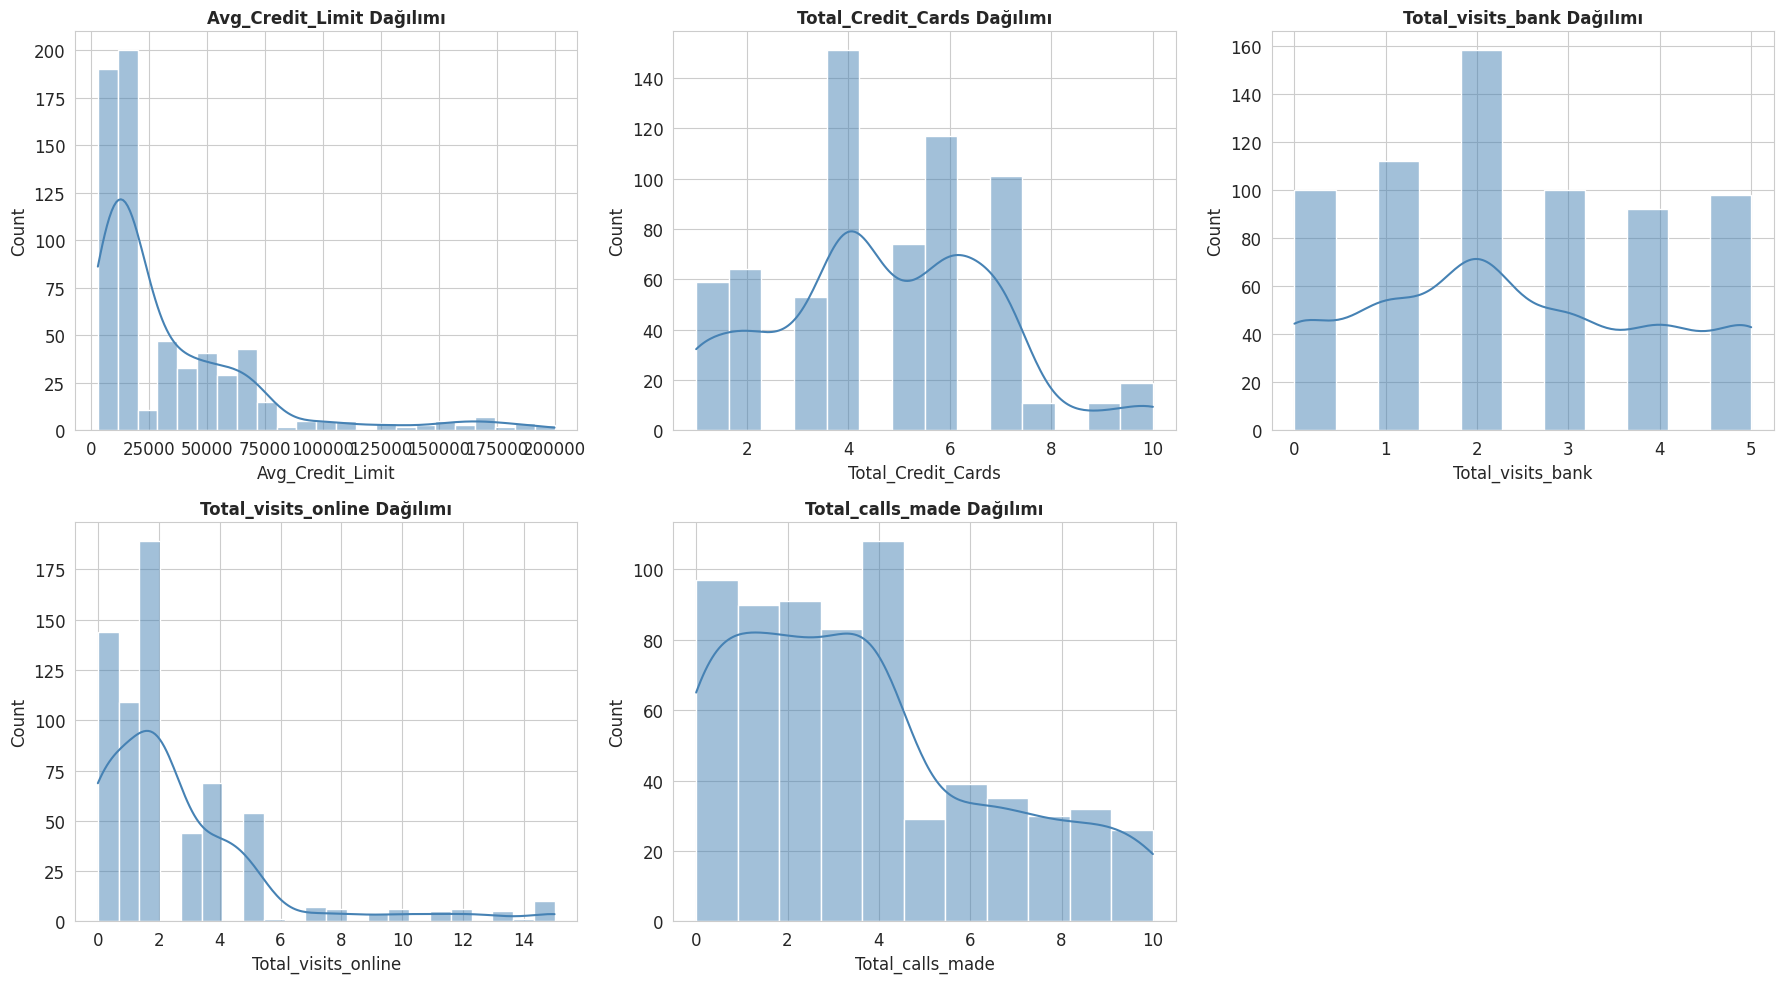

In [ ]:
#Değişkenlerin dağılımlarını görselleştirelim
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df_kopya[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Dağılımı', fontsize=12, fontweight='bold')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


In [ ]:
#Veri Önişleme
# Sl_No ve Customer Key birer kimlik sütunu olduğu için kümeleme dışında bırakılacak
df_model = df_kopya[num_cols].copy()

# Sayısal sütunlardaki eksik değerleri sütun ortalaması ile doldur (bu veri setinde eksik yok ama genel akış için uygulanıyor)
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df_model), columns=df_model.columns, index=df_model.index)

print(f'Eksik deger kaldi mi: {df_imputed.isnull().sum().sum()}')
print(f'\nVeri seti boyutu: {df_imputed.shape}')


Eksik deger kaldi mi: 0

Veri seti boyutu: (660, 5)


In [ ]:
#Standardizasyon
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)
X_scaled = pd.DataFrame(X_scaled, columns=df_imputed.columns, index=df_imputed.index)

print("Ölçeklendirilmiş Verinin ilk beş satırı: ")
print(X_scaled.head())


Ölçeklendirilmiş Verinin ilk beş satırı: 
   Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
0          1.740187           -1.249225          -0.860451   
1          0.410293           -0.787585          -1.473731   
2          0.410293            1.058973          -0.860451   
3         -0.121665            0.135694          -0.860451   
4          1.740187            0.597334          -1.473731   

   Total_visits_online  Total_calls_made  
0            -0.547490         -1.251537  
1             2.520519          1.891859  
2             0.134290          0.145528  
3            -0.547490          0.145528  
4             3.202298         -0.203739  


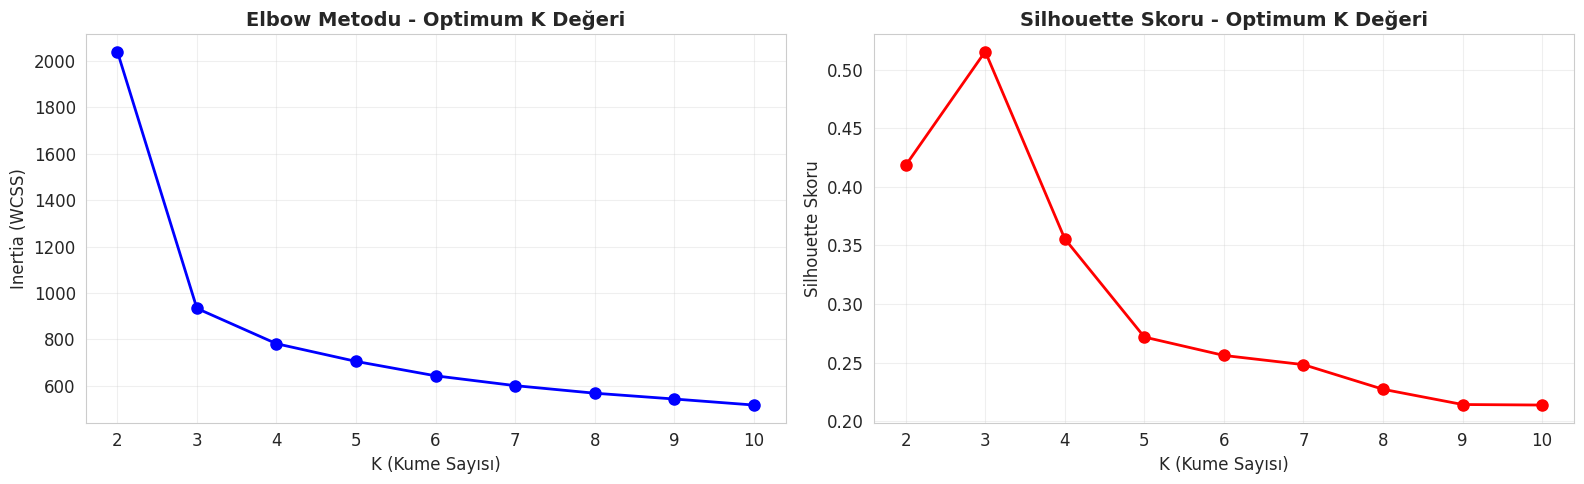

K değerine göre Silhouette Skorları:
K=2: 0.4184
K=3: 0.5157
K=4: 0.3557
K=5: 0.2717
K=6: 0.2560
K=7: 0.2482
K=8: 0.2271
K=9: 0.2141
K=10: 0.2137


In [ ]:
# Tüm sayısal sütunları kullanarak kümeleme yapalım
X_cluster = X_scaled.copy()

# Elbow metodu ile optimum K değeri
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

# Görselleştirelim
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Değeri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayısı)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Değeri', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Kume Sayısı)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('K değerine göre Silhouette Skorları:')
for k, s in zip(K_range, silhouette_scores):
    print(f'K={k}: {s:.4f}')


In [ ]:
#Optimum K ile K-Means modelini eğitiyoruz
optimal_k = silhouette_scores.index(max(silhouette_scores)) + list(K_range)[0]  # Silhouette skoruna göre en iyi k
print(f'Silhouette skoruna göre seçilen optimal K: {optimal_k}')

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

print('\nK-Means Kümeleme Sonuçları:')
print(f'Küme sayısı: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_cluster, kmeans_labels):.4f}')
print(f'Davies-Bouldin İndeksi: {davies_bouldin_score(X_cluster, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_cluster, kmeans_labels):.4f}')
print(f'\nKüme dağılımı:')
print(pd.Series(kmeans_labels).value_counts().sort_index())


Silhouette skoruna göre seçilen optimal K: 3

K-Means Kümeleme Sonuçları:
Küme sayısı: 3
Silhouette Skoru: 0.5157
Davies-Bouldin İndeksi: 0.6797
Calinski-Harabasz Skoru: 833.3426

Küme dağılımı:
0    386
1     50
2    224
Name: count, dtype: int64


In [ ]:
#K-Means kümelerinin özetleri
df_result = df_kopya.copy()
df_result['KMeans_Cluster'] = kmeans_labels
cluster_summary = df_result.groupby('KMeans_Cluster')[num_cols].mean().round(2)
print("K-Means Küme Profilleri (Ortalama Değerler):")
print(cluster_summary)


K-Means Küme Profilleri (Ortalama Değerler):
                Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
KMeans_Cluster                                                            
0                       33782.38                5.52               3.49   
1                      141040.00                8.74               0.60   
2                       12174.11                2.41               0.93   

                Total_visits_online  Total_calls_made  
KMeans_Cluster                                         
0                              0.98              2.00  
1                             10.90              1.08  
2                              3.55              6.87  


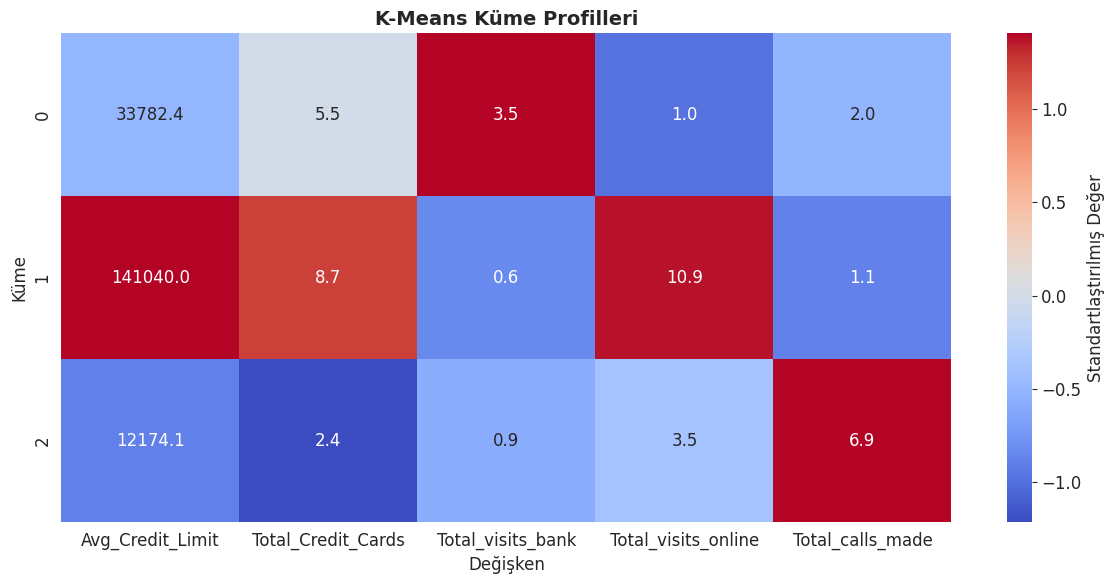

In [ ]:
#Küme profillerini görselleştirelim
cluster_summary_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_summary),
    columns=cluster_summary.columns,
    index=cluster_summary.index
)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary_scaled, annot=cluster_summary.values, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Standartlaştırılmış Değer'})
plt.title('K-Means Küme Profilleri', fontsize=14, fontweight='bold')
plt.xlabel('Değişken')
plt.ylabel('Küme')
plt.tight_layout()
plt.show()


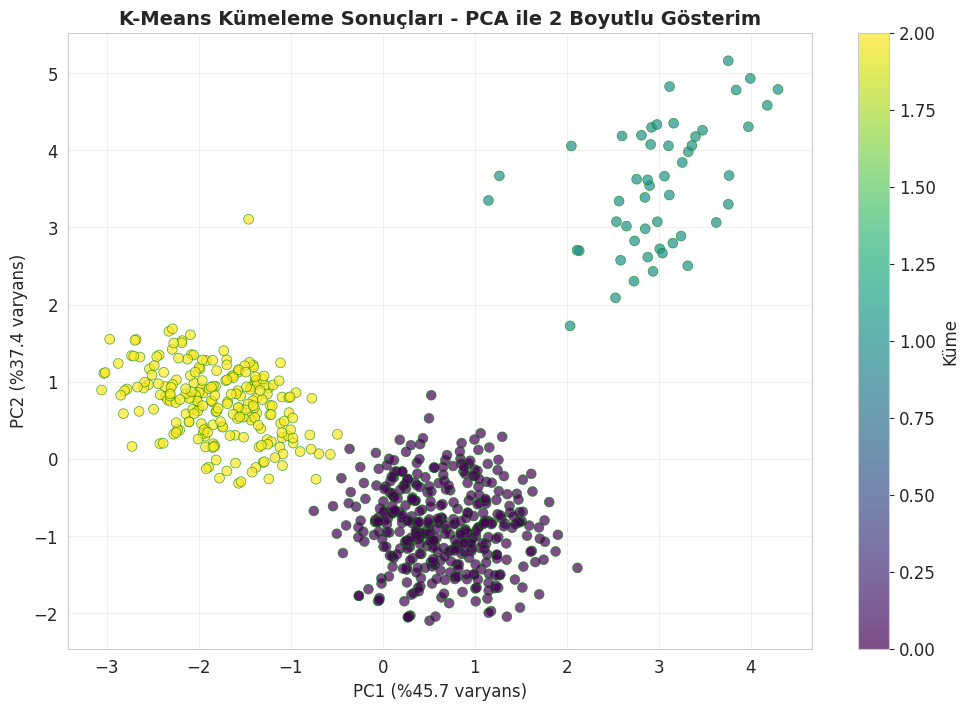

In [ ]:
# PCA ile K-Means Görselleştirmesi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='green', linewidth=0.5)
plt.colorbar(scatter, label='Küme')
plt.title('K-Means Kümeleme Sonuçları - PCA ile 2 Boyutlu Gösterim', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


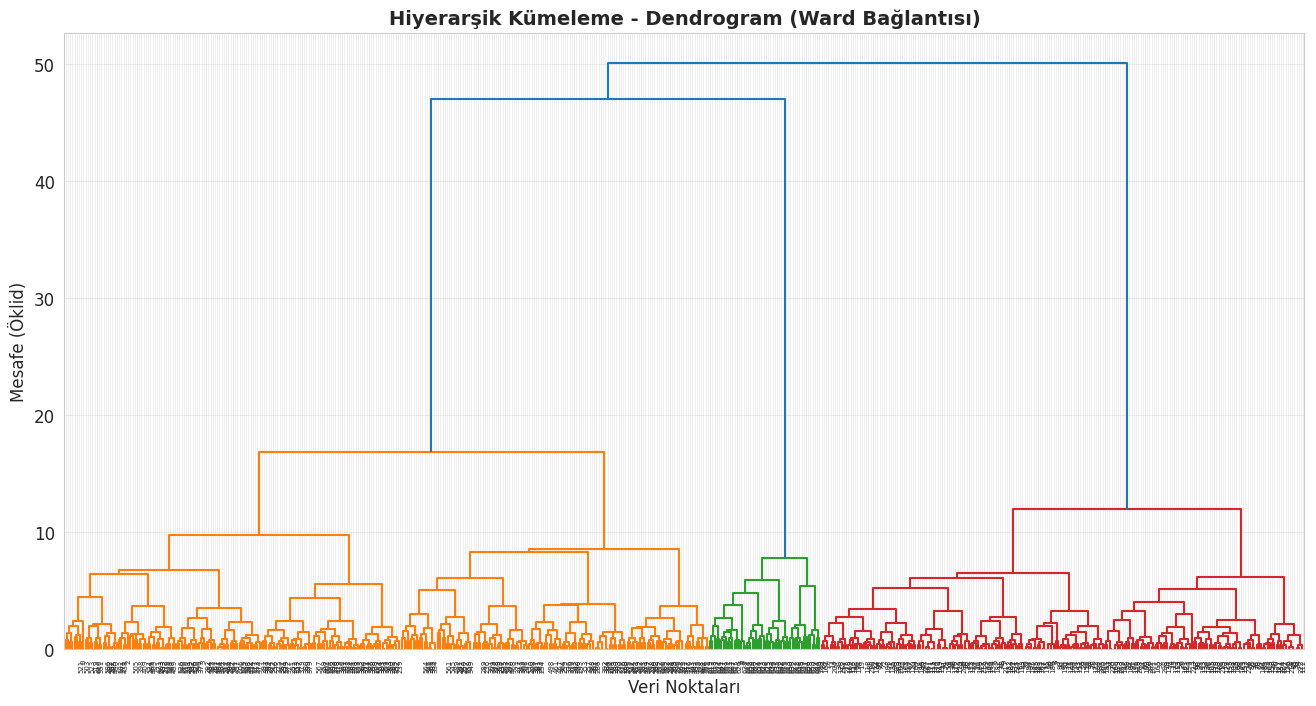

In [ ]:
# Dendrogram (Bağlantı yöntemi: ward)
plt.figure(figsize=(16, 8))
linked = linkage(X_cluster, method='ward')
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarşik Kümeleme - Dendrogram (Ward Bağlantısı)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktaları', fontsize=12)
plt.ylabel('Mesafe (Öklid)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
#Agglomerative Clustering Modeli
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_cluster)

print('Hiyerarşik Kümeleme (Agglomerative) Sonuçları:')
print(f'Küme sayısı: {optimal_k}')
print(f'Bağlantı yöntemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_cluster, agg_labels):.4f}')
print(f'Davies-Bouldin İndeksi: {davies_bouldin_score(X_cluster, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_cluster, agg_labels):.4f}')
print(f'\nKüme dağılımı:')
print(pd.Series(agg_labels).value_counts().sort_index())


Hiyerarşik Kümeleme (Agglomerative) Sonuçları:
Küme sayısı: 3
Bağlantı yöntemi: ward
Silhouette Skoru: 0.5148
Davies-Bouldin İndeksi: 0.6810
Calinski-Harabasz Skoru: 831.9308

Küme dağılımı:
0    385
1    225
2     50
Name: count, dtype: int64


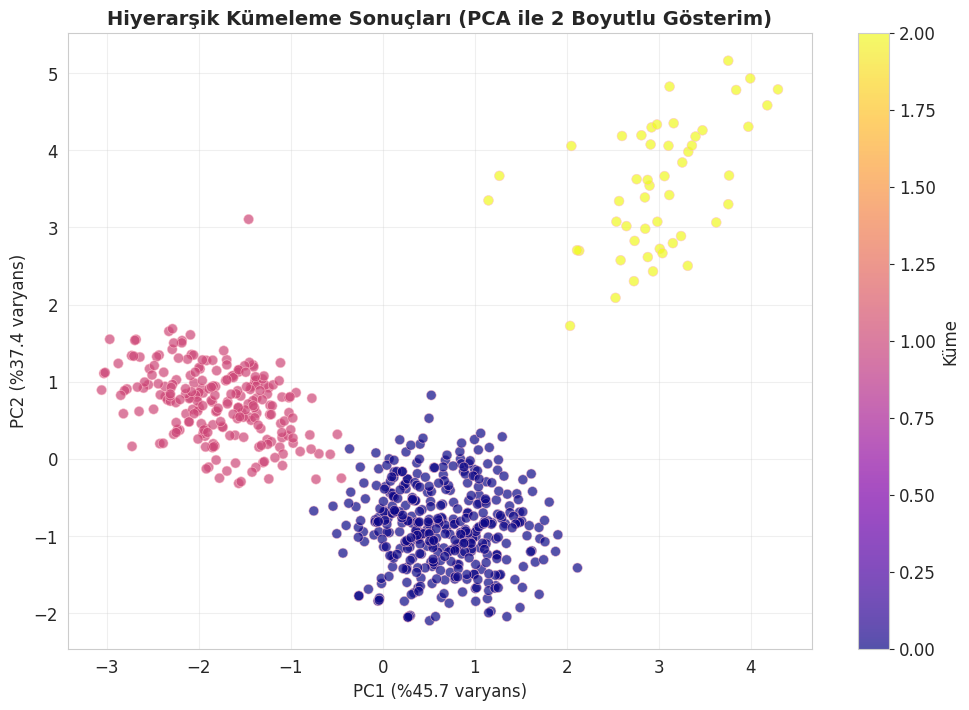

In [ ]:
# Hiyerarşik kümelerin görselleştirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='pink', linewidth=0.5)
plt.colorbar(scatter, label='Küme')
plt.title('Hiyerarşik Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


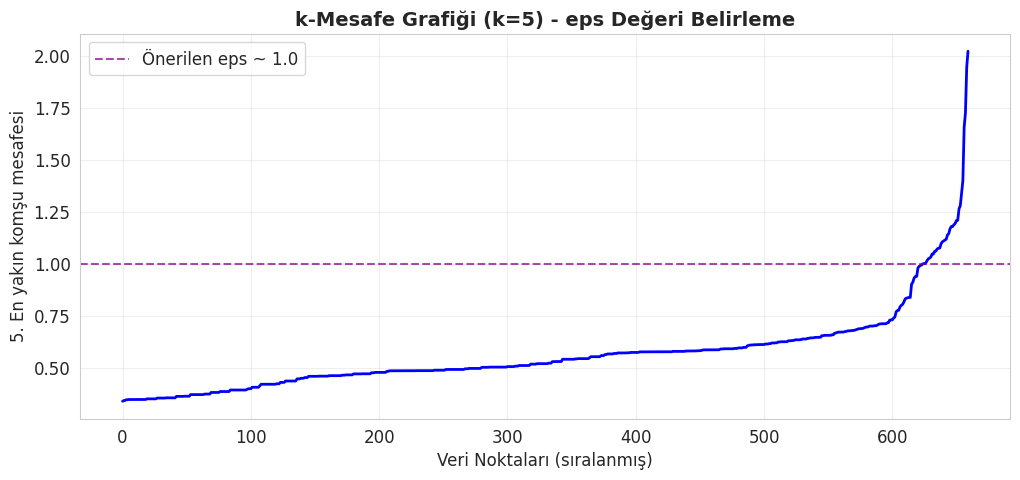

In [ ]:
#DBSCAN için eps değeri belirliyoruz
#K-distance grafiği
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_cluster)
distances, indices = neighbors_fit.kneighbors(X_cluster)

# 5. en yakın komşu mesafelerini sıralayalım
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafiği (k=5) - eps Değeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktaları (sıralanmış)', fontsize=12)
plt.ylabel('5. En yakın komşu mesafesi', fontsize=12)
plt.axhline(y=1.0, color='purple', linestyle='--', alpha=0.7, label='Önerilen eps ~ 1.0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# DBSCAN modeli
dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_cluster)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kümeleme Sonuçları:')
print(f'eps: 1.0, min_samples: 5')
print(f'Oluşan küme sayısı: {n_clusters_db}')
print(f'Gürültü (aykırı değer) sayısı: {n_noise}')
print(f'Gürültü oranı: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(X_cluster, dbscan_labels):.4f}')
    print(f'Davies-Bouldin İndeksi: {davies_bouldin_score(X_cluster, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_cluster, dbscan_labels):.4f}')

print(f'\nKüme dağılımı:')
print(pd.Series(dbscan_labels).value_counts().sort_index())


DBSCAN Kümeleme Sonuçları:
eps: 1.0, min_samples: 5
Oluşan küme sayısı: 2
Gürültü (aykırı değer) sayısı: 18
Gürültü oranı: 2.73%
Silhouette Skoru: 0.5212
Davies-Bouldin İndeksi: 2.1613
Calinski-Harabasz Skoru: 177.1071

Küme dağılımı:
-1     18
 0    608
 1     34
Name: count, dtype: int64


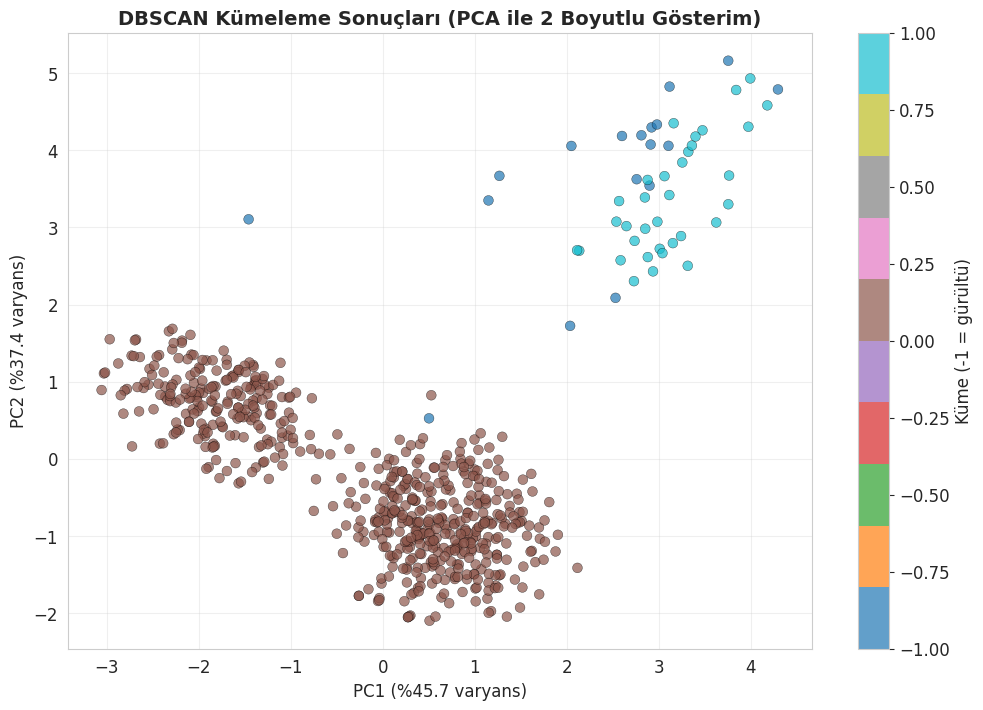

In [ ]:
#DBSCAN kümelerinin görselleştirilmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, label='Küme (-1 = gürültü)')
plt.title('DBSCAN Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
#Üç yöntemin karşılaştırılması
comparison = pd.DataFrame({
    'Yöntem': ['K-Means', 'Hiyerarşik (Agglomerative)', 'DBSCAN'],
    'Küme Sayısı': [optimal_k, optimal_k, n_clusters_db],
    'Silhouette Skoru': [
        silhouette_score(X_cluster, kmeans_labels),
        silhouette_score(X_cluster, agg_labels),
        silhouette_score(X_cluster, dbscan_labels) if n_clusters_db > 1 else np.nan
    ],
    'Davies-Bouldin İndeksi': [
        davies_bouldin_score(X_cluster, kmeans_labels),
        davies_bouldin_score(X_cluster, agg_labels),
        davies_bouldin_score(X_cluster, dbscan_labels) if n_clusters_db > 1 else np.nan
    ]
})
print(comparison.round(4).to_string(index=False))


                    Yöntem  Küme Sayısı  Silhouette Skoru  Davies-Bouldin İndeksi
                   K-Means            3            0.5157                  0.6797
Hiyerarşik (Agglomerative)            3            0.5148                  0.6810
                    DBSCAN            2            0.5212                  2.1613
